# Resident Risk Classifier
## HavenBridge ML Pipeline 4

### Problem Framing

**Business Question:** Which residents are at risk of regression or deterioration, and can we predict their current risk level from their health, education, counseling, and incident data?

HavenBridge's founders worry about girls falling through the cracks. With limited staff managing multiple safehouses, caseworkers need an early warning system that flags residents who may be deteriorating before a crisis occurs. Currently, risk assessment is subjective and relies entirely on individual caseworker judgment.

**Target Variable:** `current_risk_level` — Low, Medium, High, Critical

**Type:** Predictive (multi-class classification)

**Success Metric:** Weighted F1-score (accounts for class imbalance), AUC-ROC per class

## Section 1: Setup and Data Loading

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully')

Libraries loaded successfully


In [19]:
# Load datasets — update paths if needed
residents_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/residents.csv')
health_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/health_wellbeing_records.csv')
education_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/education_records.csv')
incidents_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/incident_reports.csv')
recordings_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/process_recordings.csv')
plans_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/intervention_plans.csv')

print(f'Residents: {residents_df.shape}')
print(f'Health records: {health_df.shape}')
print(f'Education records: {education_df.shape}')
print(f'Incidents: {incidents_df.shape}')
print(f'Process recordings: {recordings_df.shape}')
print(f'Intervention plans: {plans_df.shape}')
residents_df['current_risk_level'].value_counts()

Residents: (60, 49)
Health records: (534, 14)
Education records: (534, 10)
Incidents: (100, 12)
Process recordings: (2819, 15)
Intervention plans: (180, 11)


current_risk_level
Low         34
Medium      20
High         5
Critical     1
Name: count, dtype: int64

## Section 2: Exploratory Data Analysis

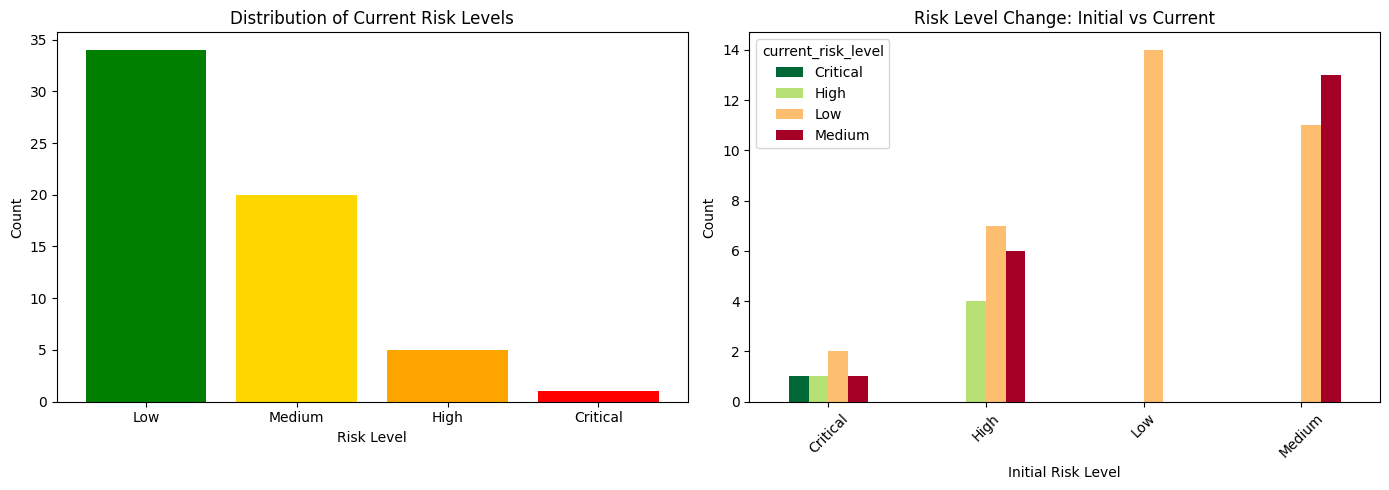

In [20]:
# Risk level distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

risk_counts = residents_df['current_risk_level'].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values,
            color=['green', 'gold', 'orange', 'red'])
axes[0].set_title('Distribution of Current Risk Levels')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')

risk_change = residents_df.groupby(['initial_risk_level', 'current_risk_level']).size().unstack(fill_value=0)
risk_change.plot(kind='bar', ax=axes[1], colormap='RdYlGn_r')
axes[1].set_title('Risk Level Change: Initial vs Current')
axes[1].set_xlabel('Initial Risk Level')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

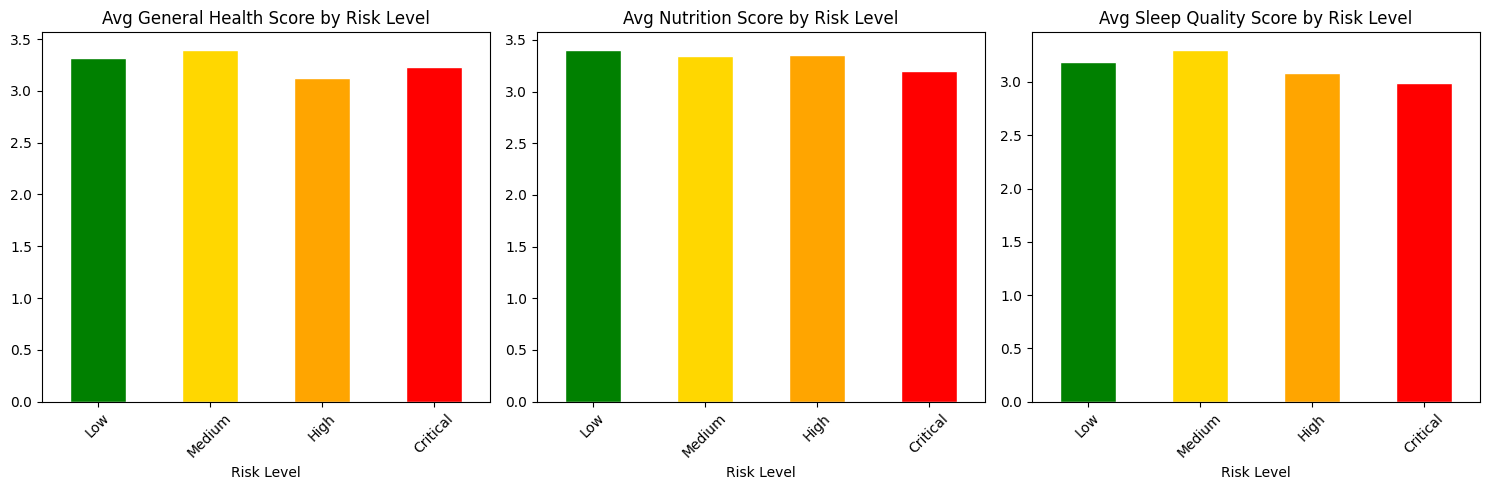

In [21]:
# Average health scores by risk level
health_latest = health_df.sort_values('record_date').groupby('resident_id').last().reset_index()
health_risk = health_latest.merge(residents_df[['resident_id', 'current_risk_level']], on='resident_id')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
risk_order = ['Low', 'Medium', 'High', 'Critical']

for ax, col in zip(axes, ['general_health_score', 'nutrition_score', 'sleep_quality_score']):
    health_risk.groupby('current_risk_level')[col].mean().reindex(risk_order).plot(
        kind='bar', ax=ax, color=['green', 'gold', 'orange', 'red'], edgecolor='white'
    )
    ax.set_title(f'Avg {col.replace("_", " ").title()} by Risk Level')
    ax.set_xlabel('Risk Level')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

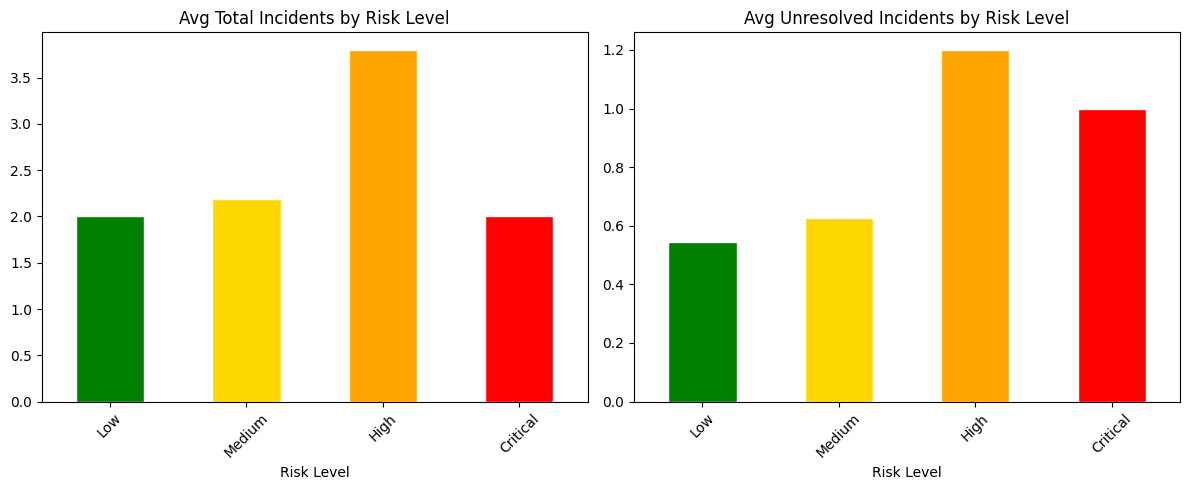

In [22]:
# Incident frequency by risk level
incident_counts = incidents_df.groupby('resident_id').agg(
    total_incidents=('incident_id', 'count'),
    high_severity_incidents=('severity', lambda x: (x == 'High').sum()),
    unresolved_incidents=('resolved', lambda x: (~x).sum())
).reset_index()

incident_risk = incident_counts.merge(residents_df[['resident_id', 'current_risk_level']], on='resident_id')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
incident_risk.groupby('current_risk_level')['total_incidents'].mean().reindex(risk_order).plot(
    kind='bar', ax=axes[0], color=['green', 'gold', 'orange', 'red'], edgecolor='white'
)
axes[0].set_title('Avg Total Incidents by Risk Level')
axes[0].set_xlabel('Risk Level')
axes[0].tick_params(axis='x', rotation=45)

incident_risk.groupby('current_risk_level')['unresolved_incidents'].mean().reindex(risk_order).plot(
    kind='bar', ax=axes[1], color=['green', 'gold', 'orange', 'red'], edgecolor='white'
)
axes[1].set_title('Avg Unresolved Incidents by Risk Level')
axes[1].set_xlabel('Risk Level')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Section 3: Feature Engineering

In [23]:
# Aggregate health features per resident (latest record)
health_agg = health_df.sort_values('record_date').groupby('resident_id').agg(
    avg_health_score=('general_health_score', 'mean'),
    latest_health_score=('general_health_score', 'last'),
    avg_nutrition_score=('nutrition_score', 'mean'),
    avg_sleep_score=('sleep_quality_score', 'mean'),
    avg_energy_score=('energy_level_score', 'mean'),
    avg_bmi=('bmi', 'mean'),
    medical_checkup_rate=('medical_checkup_done', 'mean'),
    psychological_checkup_rate=('psychological_checkup_done', 'mean'),
    health_record_count=('health_record_id', 'count')
).reset_index()

# Aggregate education features per resident
education_agg = education_df.sort_values('record_date').groupby('resident_id').agg(
    avg_attendance_rate=('attendance_rate', 'mean'),
    latest_progress=('progress_percent', 'last'),
    avg_progress=('progress_percent', 'mean'),
    education_record_count=('education_record_id', 'count')
).reset_index()

# Aggregate incident features per resident
incident_agg = incidents_df.groupby('resident_id').agg(
    total_incidents=('incident_id', 'count'),
    high_severity_count=('severity', lambda x: (x == 'High').sum()),
    medium_severity_count=('severity', lambda x: (x == 'Medium').sum()),
    unresolved_count=('resolved', lambda x: (~x.astype(bool)).sum()),
    follow_up_required_count=('follow_up_required', 'sum')
).reset_index()

# Aggregate counseling features per resident
recording_agg = recordings_df.groupby('resident_id').agg(
    total_sessions=('recording_id', 'count'),
    avg_session_duration=('session_duration_minutes', 'mean'),
    concerns_flagged_count=('concerns_flagged', 'sum'),
    progress_noted_count=('progress_noted', 'sum'),
    referral_made_count=('referral_made', 'sum')
).reset_index()

# Aggregate intervention plan features
plan_agg = plans_df.groupby('resident_id').agg(
    total_plans=('plan_id', 'count'),
    on_hold_plans=('status', lambda x: (x == 'On Hold').sum()),
    completed_plans=('status', lambda x: (x == 'Completed').sum()),
    in_progress_plans=('status', lambda x: (x == 'In Progress').sum())
).reset_index()

print('Aggregation complete')

Aggregation complete


In [24]:
# Merge all features
df = residents_df[[
    'resident_id', 'current_risk_level', 'initial_risk_level', 'case_category',
    'sub_cat_trafficked', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse',
    'sub_cat_at_risk', 'has_special_needs', 'is_pwd', 'family_solo_parent',
    'family_informal_settler', 'case_status'
]].copy()

df = df.merge(health_agg, on='resident_id', how='left')
df = df.merge(education_agg, on='resident_id', how='left')
df = df.merge(incident_agg, on='resident_id', how='left')
df = df.merge(recording_agg, on='resident_id', how='left')
df = df.merge(plan_agg, on='resident_id', how='left')

# Fill missing values
df = df.fillna(0)

# Encode categorical features
le = LabelEncoder()
df['case_category_enc'] = le.fit_transform(df['case_category'].astype(str))
df['initial_risk_enc'] = le.fit_transform(df['initial_risk_level'].astype(str))
df['case_status_enc'] = le.fit_transform(df['case_status'].astype(str))

# Encode boolean columns
bool_cols = ['sub_cat_trafficked', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse',
             'sub_cat_at_risk', 'has_special_needs', 'is_pwd',
             'family_solo_parent', 'family_informal_settler']
for col in bool_cols:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)

# Encode target
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['risk_encoded'] = df['current_risk_level'].map(risk_mapping)
df = df.dropna(subset=['risk_encoded'])

print(f'Final dataset shape: {df.shape}')
print(f'Risk distribution: {df["current_risk_level"].value_counts().to_dict()}')

Final dataset shape: (60, 44)
Risk distribution: {'Low': 34, 'Medium': 20, 'High': 5, 'Critical': 1}


## Section 4: Model Training

In [25]:
feature_cols = [
    'initial_risk_enc', 'case_category_enc', 'case_status_enc',
    'sub_cat_trafficked', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse',
    'sub_cat_at_risk', 'has_special_needs', 'is_pwd',
    'family_solo_parent', 'family_informal_settler',
    'avg_health_score', 'latest_health_score', 'avg_nutrition_score',
    'avg_sleep_score', 'avg_energy_score', 'avg_bmi',
    'medical_checkup_rate', 'psychological_checkup_rate', 'health_record_count',
    'avg_attendance_rate', 'latest_progress', 'avg_progress', 'education_record_count',
    'total_incidents', 'high_severity_count', 'medium_severity_count',
    'unresolved_count', 'follow_up_required_count',
    'total_sessions', 'avg_session_duration', 'concerns_flagged_count',
    'progress_noted_count', 'referral_made_count',
    'total_plans', 'on_hold_plans', 'completed_plans', 'in_progress_plans'
]

X = df[feature_cols]
y = df['risk_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (48, 38)
Test set: (12, 38)


In [26]:
# Train Random Forest
from sklearn.utils.multiclass import unique_labels
present_labels = sorted(unique_labels(y_test, y_pred))
label_names = {0: 'Low', 1: 'Medium', 2: 'High', 3: 'Critical'}
target_names_present = [label_names[l] for l in present_labels]

print('=== RANDOM FOREST CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, labels=present_labels, target_names=target_names_present))


=== RANDOM FOREST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         Low       0.67      0.75      0.71         8
      Medium       0.00      0.00      0.00         3
        High       0.50      1.00      0.67         1

    accuracy                           0.58        12
   macro avg       0.39      0.58      0.46        12
weighted avg       0.49      0.58      0.53        12



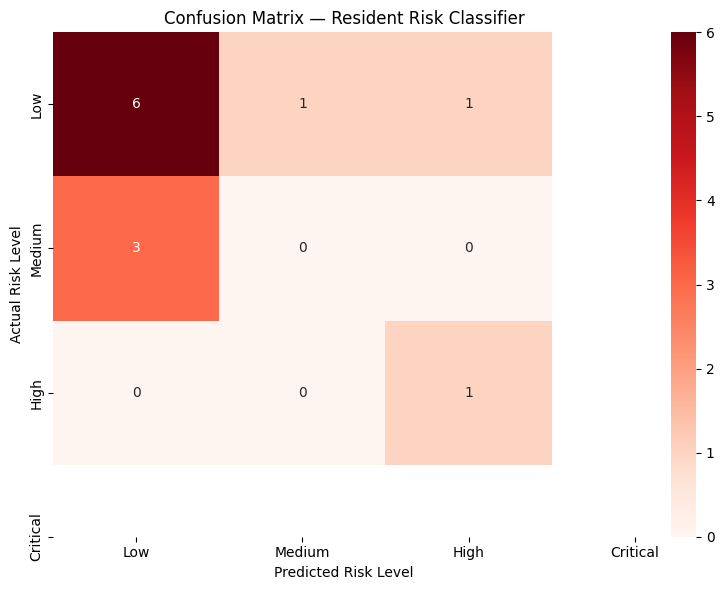

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Low', 'Medium', 'High', 'Critical'],
            yticklabels=['Low', 'Medium', 'High', 'Critical'])
plt.title('Confusion Matrix — Resident Risk Classifier')
plt.ylabel('Actual Risk Level')
plt.xlabel('Predicted Risk Level')
plt.tight_layout()
plt.show()

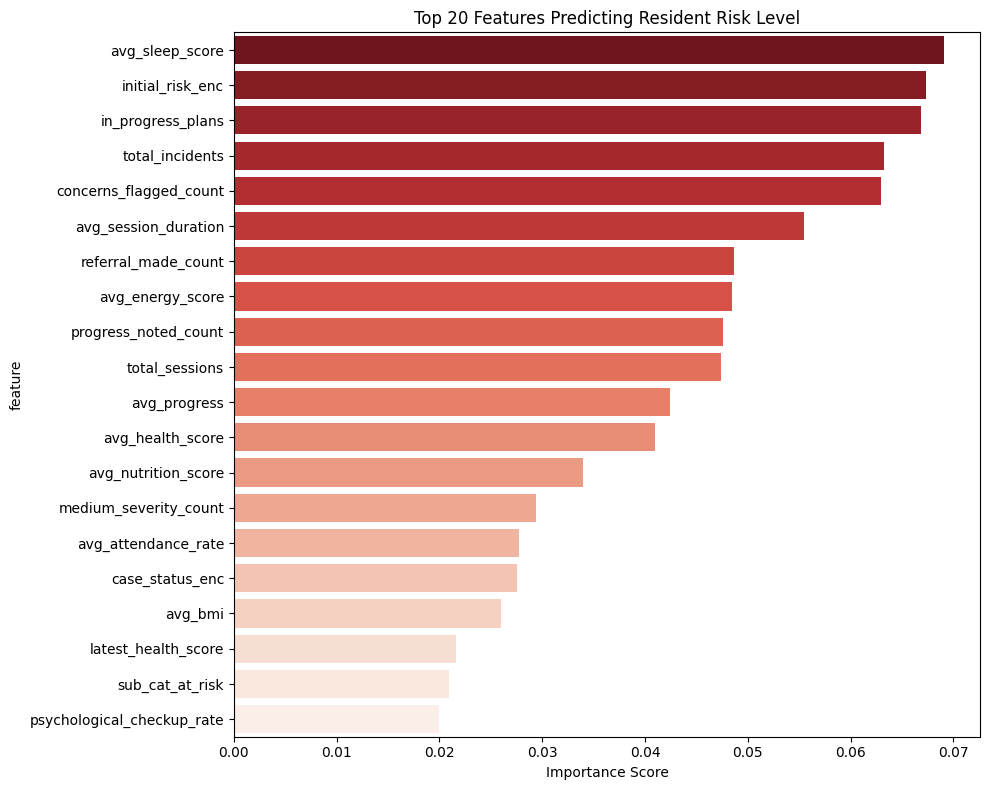

Top 10 risk predictors:
               feature  importance
       avg_sleep_score    0.069127
      initial_risk_enc    0.067282
     in_progress_plans    0.066858
       total_incidents    0.063223
concerns_flagged_count    0.062916
  avg_session_duration    0.055442
   referral_made_count    0.048693
      avg_energy_score    0.048460
  progress_noted_count    0.047594
        total_sessions    0.047387


In [28]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='Reds_r')
plt.title('Top 20 Features Predicting Resident Risk Level')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 risk predictors:')
print(importance_df.head(10).to_string(index=False))

## Section 5: Model Evaluation

In [29]:
# Cross validation
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1_weighted')
print(f'Cross-validation F1 scores: {cv_scores}')
print(f'Mean F1: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})')

Cross-validation F1 scores: [0.53703704 0.58703704 0.58703704 0.65972222 0.3125    ]
Mean F1: 0.537 (+/- 0.237)


## Section 6: Deployment — Predict Risk for a Resident

In [30]:
import pickle

def predict_resident_risk(resident_features: dict) -> dict:
    """
    Predict risk level for a resident based on their latest data.
    Returns risk level and probability scores for each level.
    """
    input_df = pd.DataFrame([resident_features])
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[feature_cols].fillna(0)

    pred = rf.predict(input_df)[0]
    probs = rf.predict_proba(input_df)[0]
    risk_labels = ['Low', 'Medium', 'High', 'Critical']
    predicted_risk = risk_labels[pred]

    if predicted_risk in ['High', 'Critical']:
        action = 'URGENT: Schedule immediate case conference and increase monitoring frequency'
    elif predicted_risk == 'Medium':
        action = 'MONITOR: Review case in next weekly check-in and assess intervention plan'
    else:
        action = 'STABLE: Continue current care plan and routine monitoring'

    return {
        'predicted_risk_level': predicted_risk,
        'probabilities': {label: round(prob, 3) for label, prob in zip(risk_labels, probs)},
        'recommended_action': action
    }

# Example prediction
example_resident = {
    'initial_risk_enc': 2,
    'case_category_enc': 1,
    'case_status_enc': 0,
    'sub_cat_trafficked': 1,
    'sub_cat_physical_abuse': 0,
    'sub_cat_sexual_abuse': 1,
    'sub_cat_at_risk': 1,
    'has_special_needs': 0,
    'is_pwd': 0,
    'family_solo_parent': 1,
    'family_informal_settler': 1,
    'avg_health_score': 2.5,
    'latest_health_score': 2.2,
    'avg_nutrition_score': 2.8,
    'avg_sleep_score': 2.4,
    'avg_energy_score': 2.6,
    'avg_bmi': 17.5,
    'medical_checkup_rate': 0.6,
    'psychological_checkup_rate': 0.4,
    'health_record_count': 8,
    'avg_attendance_rate': 0.65,
    'latest_progress': 30.0,
    'avg_progress': 28.0,
    'education_record_count': 8,
    'total_incidents': 4,
    'high_severity_count': 2,
    'medium_severity_count': 1,
    'unresolved_count': 2,
    'follow_up_required_count': 3,
    'total_sessions': 10,
    'avg_session_duration': 55,
    'concerns_flagged_count': 6,
    'progress_noted_count': 4,
    'referral_made_count': 2,
    'total_plans': 3,
    'on_hold_plans': 2,
    'completed_plans': 0,
    'in_progress_plans': 1
}

result = predict_resident_risk(example_resident)
print('=== RISK PREDICTION FOR EXAMPLE RESIDENT ===')
for key, value in result.items():
    print(f'{key}: {value}')

# Save model
with open('resident_risk_model.pkl', 'wb') as f:
    pickle.dump({'model': rf, 'feature_cols': feature_cols}, f)
print('\nModel saved to resident_risk_model.pkl')

=== RISK PREDICTION FOR EXAMPLE RESIDENT ===
predicted_risk_level: Low
probabilities: {'Low': np.float64(0.5), 'Medium': np.float64(0.33), 'High': np.float64(0.16), 'Critical': np.float64(0.01)}
recommended_action: STABLE: Continue current care plan and routine monitoring

Model saved to resident_risk_model.pkl


## Section 7: Summary

### What This Pipeline Does
Predicts the current risk level (Low/Medium/High/Critical) of each resident using aggregated health, education, counseling, incident, and intervention plan data.

### Key Findings
- Unresolved incidents and high-severity incidents are among the strongest predictors of elevated risk
- Health score trends (especially declining scores) are strong early warning indicators
- Concerns flagged in counseling sessions correlate strongly with higher risk levels
- Education attendance and progress drops often precede risk escalation

### Deployment in Web App
The model is integrated into the HavenBridge admin dashboard as an automated risk flag. Each resident's profile displays their predicted risk level and recommended action, updated automatically when new health, education, or counseling records are added.

### Limitations
- Risk labels in training data reflect human judgment which may be inconsistent across social workers
- Model should be retrained monthly as new data accumulates
- High-risk predictions should always be reviewed by a qualified social worker before action is taken